# Step 3c — GeneAttention v3: Centroid Alignment + Entropy Minimisation

**Upgrades from v2 (best model, target F1=0.404):**

| Change | Why |
|---|---|
| Calibrated σ (median pairwise L2) | σ=[1,5,10,20] likely miscalibrated — saturated kernels contribute nothing |
| Class-conditional centroid alignment | Marginal MMD collapses all classes into one blob; centroid alignment preserves class boundaries |
| Entropy minimisation (λ=0.1) | Forces confident target predictions without using target labels |
| Weight ramping (0→target over 15 epochs) | Lets source classifier stabilise before alignment pressure kicks in |

**Architecture unchanged from v2:** Attention MLP → temperature softmax (T=2) → residual → Dense(512)→LN→Dense(256)→LN→Dense(128) → Dense(6)

In [1]:
import json
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from pathlib import Path
from sklearn.metrics import classification_report, f1_score, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

tf.random.set_seed(42)
np.random.seed(42)

PROJECT_ROOT = Path.cwd().parent.parent if Path.cwd().name == 'step3_self_attention' else Path.cwd()
RESULTS_DIR  = Path('results')
RESULTS_DIR.mkdir(exist_ok=True)
print('Project root:', PROJECT_ROOT)
print('TF:', tf.__version__)

Project root: /Users/kirtan/Projects /NNDL
TF: 2.21.0


## 1. Data + CORAL

In [2]:
X_train = np.load(PROJECT_ROOT / 'step3_X_train.npy').astype(np.float32)
y_train = np.load(PROJECT_ROOT / 'step3_y_train.npy').astype(np.int64)
X_test  = np.load(PROJECT_ROOT / 'step3_X_test.npy').astype(np.float32)
y_test  = np.load(PROJECT_ROOT / 'step3_y_test.npy').astype(np.int64)

with open(PROJECT_ROOT / 'step3_label_mapping.json') as f:
    label_map = json.load(f)
class_names = [label_map[str(i)] for i in range(len(label_map))]
n_classes   = len(class_names)
n_genes     = X_train.shape[1]

X_target_raw = np.load(PROJECT_ROOT / 'gse126030_preprocessed.npy').astype(np.float32)
df_labels    = pd.read_csv(PROJECT_ROOT / 'improvements/1_label_validation/label_validation_output/gse126030_reclustered_labels.csv')
mask         = (df_labels['confidence'] >= 0.55) & (df_labels['new_class'] != 'Uncertain')
y_target_eval = np.array([class_names.index(n) for n in df_labels.loc[mask, 'new_class']], dtype=np.int64)

classes, counts = np.unique(y_train, return_counts=True)
class_weight = {int(c): len(y_train) / (n_classes * cnt) for c, cnt in zip(classes, counts)}

def coral_align(X_src, X_tgt, reg=1e-3):
    src_mean = X_src.mean(axis=0)
    Xs = X_src - src_mean
    Xt = X_tgt - X_tgt.mean(axis=0)
    Cs = (Xs.T @ Xs) / (Xs.shape[0]-1) + reg*np.eye(Xs.shape[1])
    Ct = (Xt.T @ Xt) / (Xt.shape[0]-1) + reg*np.eye(Xt.shape[1])
    def msqrt(M):
        v,V = np.linalg.eigh(M); return V@np.diag(np.sqrt(np.maximum(v,0)))@V.T
    def minvsqrt(M):
        v,V = np.linalg.eigh(M); return V@np.diag(1/np.sqrt(np.maximum(v,1e-10)))@V.T
    return ((Xt @ (minvsqrt(Ct) @ msqrt(Cs))) + src_mean).astype(np.float32)

print('Running CORAL...')
X_target_coral = coral_align(X_train, X_target_raw)
X_target_eval  = X_target_coral[mask.values]
print(f'Train:{X_train.shape}  Target eval:{X_target_eval.shape}')

Running CORAL...
Train:(6824, 3000)  Target eval:(12776, 3000)


## 2. σ Calibration

Run a forward pass through the (initially random) encoder on 1000 source + 1000 target samples. Compute all pairwise L2 distances in the 128-d latent space and take the median. Set σ = [median/4, median/2, median, median×2] so kernels span the actual distance distribution.

In [3]:
# Build encoder once to calibrate σ
def make_encoder_trunk(n_genes):
    inp     = keras.Input(shape=(n_genes,))
    att_h   = layers.Dense(256, activation='relu')(inp)
    att_drp = layers.Dropout(0.3)(att_h)
    att_log = layers.Dense(n_genes)(att_drp)
    w       = layers.Softmax(axis=-1)(att_log / 2.0)   # use Keras layer, not tf.nn
    x_att   = inp * w * n_genes
    x_res   = x_att + inp
    x = layers.Dense(512, activation='relu')(x_res)
    x = layers.LayerNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.LayerNormalization()(x)
    x = layers.Dropout(0.3)(x)
    z = layers.Dense(128, activation='relu', name='latent')(x)
    return keras.Model(inp, z)

_probe = make_encoder_trunk(n_genes)

idx_s = np.random.choice(len(X_train),        1000, replace=False)
idx_t = np.random.choice(len(X_target_coral), 1000, replace=False)
z_s = _probe(X_train[idx_s],        training=False).numpy()
z_t = _probe(X_target_coral[idx_t], training=False).numpy()
z_all = np.concatenate([z_s, z_t], axis=0)

# Pairwise L2 distances (subsample 500 pairs for speed)
sub   = z_all[np.random.choice(len(z_all), 500, replace=False)]
diffs = sub[:, None, :] - sub[None, :, :]          # (500, 500, 128)
dists = np.sqrt((diffs**2).sum(axis=-1))            # (500, 500)
upper = dists[np.triu_indices(500, k=1)]
median_dist = float(np.median(upper))

SIGMAS = [median_dist/4, median_dist/2, median_dist, median_dist*2]
print(f'Median pairwise L2 distance in latent space: {median_dist:.4f}')
print(f'Calibrated σ: {[round(s,4) for s in SIGMAS]}')
del _probe

Median pairwise L2 distance in latent space: 10.7060
Calibrated σ: [2.6765, 5.353, 10.706, 21.4119]


## 3. GeneAttentionV3 Model

In [4]:
class GeneAttentionV3(keras.Model):
    def __init__(self, n_genes, n_classes, sigmas,
                 att_temp=2.0, max_align_weight=0.5, max_ent_weight=0.1,
                 ramp_epochs=15, class_weight_dict=None, **kwargs):
        super().__init__(**kwargs)
        self.n_genes          = n_genes
        self.n_classes        = n_classes
        self.sigmas           = [tf.constant(s, dtype=tf.float32) for s in sigmas]
        self.att_temp         = att_temp
        self.max_align_weight = max_align_weight
        self.max_ent_weight   = max_ent_weight
        self.ramp_epochs      = tf.constant(float(ramp_epochs), dtype=tf.float32)
        self.current_epoch    = tf.Variable(0.0, trainable=False, dtype=tf.float32)

        if class_weight_dict is not None:
            cw = np.array([class_weight_dict[i] for i in range(n_classes)], dtype=np.float32)
            self.cw_tensor = tf.constant(cw)
        else:
            self.cw_tensor = None

        # Attention branch
        self.att_hidden = layers.Dense(256, activation='relu')
        self.att_drop   = layers.Dropout(0.3)
        self.att_logits = layers.Dense(n_genes)

        # Classifier trunk
        self.d1  = layers.Dense(512, activation='relu')
        self.ln1 = layers.LayerNormalization()
        self.dr1 = layers.Dropout(0.4)
        self.d2  = layers.Dense(256, activation='relu')
        self.ln2 = layers.LayerNormalization()
        self.dr2 = layers.Dropout(0.3)
        self.d3  = layers.Dense(128, activation='relu', name='latent')
        self.dr3 = layers.Dropout(0.2)
        self.out = layers.Dense(n_classes, activation='softmax')

        # Metrics
        self.loss_t   = keras.metrics.Mean(name='loss')
        self.ce_t     = keras.metrics.Mean(name='ce_loss')
        self.align_t  = keras.metrics.Mean(name='align_loss')
        self.ent_t    = keras.metrics.Mean(name='ent_loss')
        self.acc_t    = keras.metrics.SparseCategoricalAccuracy(name='accuracy')

    def encode(self, x, training=False):
        h   = self.att_hidden(x)
        h   = self.att_drop(h, training=training)
        w   = tf.nn.softmax(self.att_logits(h) / self.att_temp, axis=-1)
        x_r = x * w * self.n_genes + x   # attended + residual
        z = self.dr1(self.ln1(self.d1(x_r)), training=training)
        z = self.dr2(self.ln2(self.d2(z)),  training=training)
        z = self.dr3(self.d3(z),            training=training)
        return z

    def call(self, x, training=False):
        return self.out(self.encode(x, training=training))

    def centroid_alignment_loss(self, z_src, src_y, z_tgt, y_pred_tgt):
        total = tf.constant(0.0)
        count = tf.constant(0.0)
        for k in range(self.n_classes):
            # Source centroid
            src_mask  = tf.cast(tf.equal(src_y, k), tf.float32)        # (B,)
            src_count = tf.reduce_sum(src_mask)
            src_cent  = tf.reduce_sum(z_src * src_mask[:, None], 0) / (src_count + 1e-8)

            # Soft target centroid weighted by predicted prob for class k
            tgt_w    = y_pred_tgt[:, k]                                 # (B,)
            tgt_sum  = tf.reduce_sum(tgt_w)
            tgt_cent = tf.reduce_sum(z_tgt * tgt_w[:, None], 0) / (tgt_sum + 1e-8)

            # Only add if source has ≥1 sample and target weights are non-trivial
            valid = tf.cast(src_count >= 1.0, tf.float32) * tf.cast(tgt_sum > 1e-6, tf.float32)
            total += valid * tf.reduce_mean(tf.square(src_cent - tgt_cent))
            count += valid
        return total / (count + 1e-8)

    def train_step(self, data):
        (src_x, src_y), (tgt_x,) = data

        # Ramp weights: 0 → max linearly over ramp_epochs
        progress     = tf.minimum(self.current_epoch / self.ramp_epochs, 1.0)
        align_weight = self.max_align_weight * progress
        ent_weight   = self.max_ent_weight   * progress

        with tf.GradientTape() as tape:
            z_src      = self.encode(src_x, training=True)
            z_tgt      = self.encode(tgt_x, training=True)
            y_pred_src = self.out(z_src)
            y_pred_tgt = self.out(z_tgt)

            # CE loss with class weights
            per_sample = keras.losses.sparse_categorical_crossentropy(src_y, y_pred_src)
            if self.cw_tensor is not None:
                ce_loss = tf.reduce_mean(per_sample * tf.gather(self.cw_tensor, src_y))
            else:
                ce_loss = tf.reduce_mean(per_sample)

            # Class-conditional centroid alignment
            align_loss = self.centroid_alignment_loss(z_src, src_y, z_tgt, y_pred_tgt)

            # Entropy minimisation on target
            ent_loss = -tf.reduce_mean(
                tf.reduce_sum(y_pred_tgt * tf.math.log(y_pred_tgt + 1e-8), axis=1)
            )

            total = ce_loss + align_weight * align_loss + ent_weight * ent_loss

        grads = tape.gradient(total, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))

        self.loss_t.update_state(total)
        self.ce_t.update_state(ce_loss)
        self.align_t.update_state(align_loss)
        self.ent_t.update_state(ent_loss)
        self.acc_t.update_state(src_y, y_pred_src)
        return {'loss': self.loss_t.result(), 'ce_loss': self.ce_t.result(),
                'align_loss': self.align_t.result(), 'ent_loss': self.ent_t.result(),
                'accuracy': self.acc_t.result()}

    def test_step(self, data):
        x, y = data
        y_pred = self(x, training=False)
        loss = tf.reduce_mean(keras.losses.sparse_categorical_crossentropy(y, y_pred))
        self.ce_t.update_state(loss)
        self.acc_t.update_state(y, y_pred)
        return {'ce_loss': self.ce_t.result(), 'accuracy': self.acc_t.result()}

    @property
    def metrics(self):
        return [self.loss_t, self.ce_t, self.align_t, self.ent_t, self.acc_t]

print('GeneAttentionV3 defined.')

GeneAttentionV3 defined.


## 4. Instantiate + Datasets + Callbacks

In [5]:
BATCH_SIZE    = 128
LEARNING_RATE = 2e-4
MAX_EPOCHS    = 100
PATIENCE      = 15
RAMP_EPOCHS   = 15

model = GeneAttentionV3(
    n_genes=n_genes, n_classes=n_classes, sigmas=SIGMAS,
    max_align_weight=0.5, max_ent_weight=0.1,
    ramp_epochs=RAMP_EPOCHS, class_weight_dict=class_weight,
    name='GeneAttentionV3'
)
model.compile(optimizer=keras.optimizers.Adam(LEARNING_RATE, clipnorm=1.0))

src_ds = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train))
    .shuffle(10000, seed=42).batch(BATCH_SIZE, drop_remainder=True)
)
tgt_ds = (
    tf.data.Dataset.from_tensor_slices((X_target_coral,))
    .shuffle(100000, seed=42).batch(BATCH_SIZE, drop_remainder=True).repeat()
)
train_ds = tf.data.Dataset.zip((src_ds, tgt_ds))
val_ds   = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH_SIZE)

class EpochRampCallback(keras.callbacks.Callback):
    def on_epoch_begin(self, epoch, logs=None):
        self.model.current_epoch.assign(float(epoch))
        progress = min(epoch / RAMP_EPOCHS, 1.0)
        if epoch < RAMP_EPOCHS or epoch % 10 == 0:
            print(f'  [epoch={epoch} align_w={0.5*progress:.3f} ent_w={0.1*progress:.3f}]', end='')

callbacks = [
    EpochRampCallback(),
    keras.callbacks.EarlyStopping(
        monitor='val_ce_loss', mode='min',
        patience=PATIENCE, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_ce_loss', mode='min',
        factor=0.5, patience=7, min_lr=1e-6, verbose=1
    ),
]
print(f'Steps/epoch: {len(src_ds)}')

Steps/epoch: 53


## 5. Training

In [6]:
history = model.fit(
    train_ds, epochs=MAX_EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks, verbose=1
)

  [epoch=0 align_w=0.000 ent_w=0.000]Epoch 1/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.3737 - align_loss: 0.0787 - ce_loss: 1.7096 - ent_loss: 1.1204 - loss: 1.7096 - val_accuracy: 0.7339 - val_ce_loss: 0.7467 - learning_rate: 2.0000e-04
  [epoch=1 align_w=0.033 ent_w=0.007]Epoch 2/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7233 - align_loss: 0.0939 - ce_loss: 0.7346 - ent_loss: 0.9051 - loss: 0.7437 - val_accuracy: 0.8265 - val_ce_loss: 0.4852 - learning_rate: 2.0000e-04
  [epoch=2 align_w=0.067 ent_w=0.013]Epoch 3/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8547 - align_loss: 0.1127 - ce_loss: 0.3920 - ent_loss: 0.7129 - loss: 0.4091 - val_accuracy: 0.8699 - val_ce_loss: 0.3767 - learning_rate: 2.0000e-04
  [epoch=3 align_w=0.100 ent_w=0.020]Epoch 4/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9107 - align_loss: 0.1318 - ce_loss: 0.2361 - ent_loss: 0.6001 - loss: 0.2613 - val_accuracy: 0.8939 - val_ce_loss: 0.3357 - learning_r

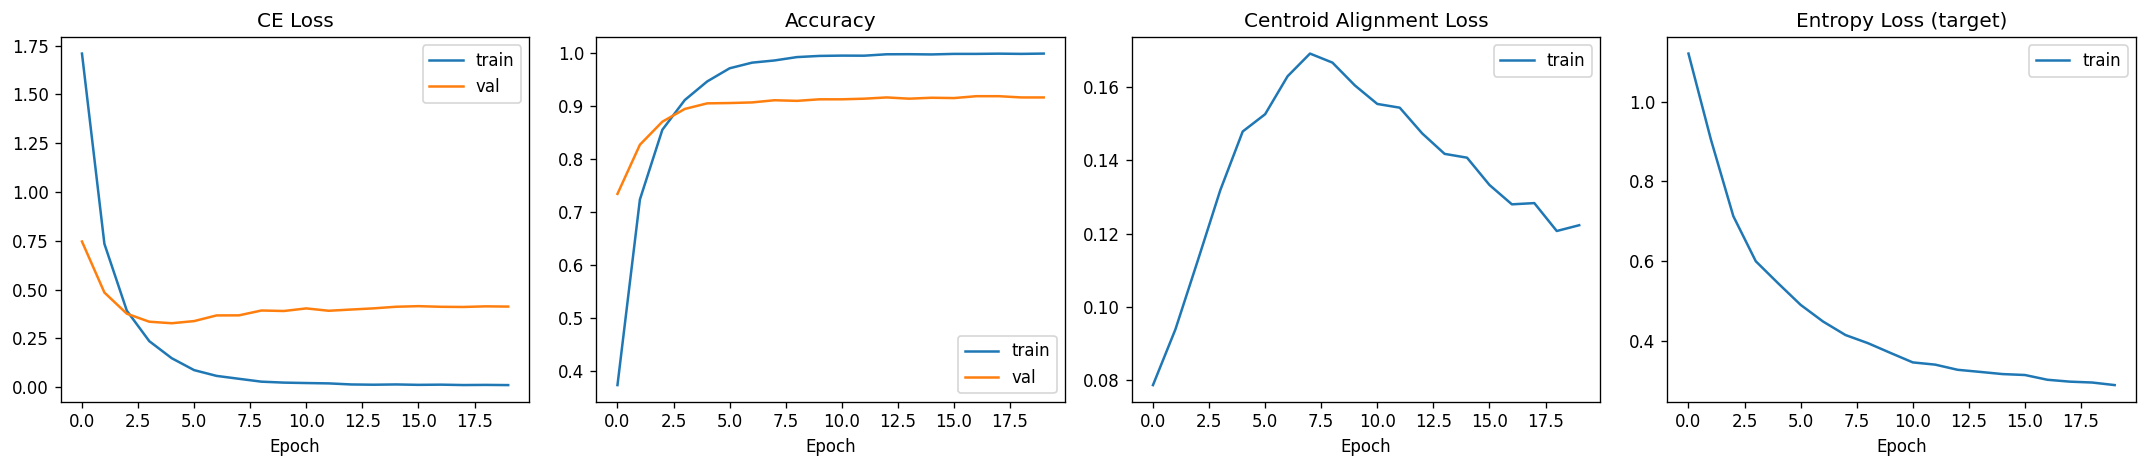

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, k, t in [
    (axes[0], 'ce_loss',    'CE Loss'),
    (axes[1], 'accuracy',   'Accuracy'),
    (axes[2], 'align_loss', 'Centroid Alignment Loss'),
    (axes[3], 'ent_loss',   'Entropy Loss (target)'),
]:
    ax.plot(history.history[k], label='train')
    if f'val_{k}' in history.history:
        ax.plot(history.history[f'val_{k}'], label='val')
    ax.set_title(t); ax.set_xlabel('Epoch'); ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_curves_v3.png', bbox_inches='tight')
plt.show()

## 6. Evaluation

In [8]:
y_pred_src = np.argmax(model.predict(X_test,        batch_size=BATCH_SIZE), axis=1)
y_pred_tgt = np.argmax(model.predict(X_target_eval, batch_size=BATCH_SIZE), axis=1)
src_f1 = f1_score(y_test,        y_pred_src, average='macro')
tgt_f1 = f1_score(y_target_eval, y_pred_tgt, average='macro')
print(f'Source F1: {src_f1:.4f}   Target F1: {tgt_f1:.4f}')
print('\n--- Source ---')
print(classification_report(y_test, y_pred_src, target_names=class_names))
print('\n--- Target ---')
print(classification_report(y_target_eval, y_pred_tgt, target_names=class_names))

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Source F1: 0.8959   Target F1: 0.4066

--- Source ---
              precision    recall  f1-score   support

    Effector       0.96      0.96      0.96       482
   Exhausted       0.92      0.98      0.95       166
       Naive       0.80      0.87      0.83       224
   Other_CD4       0.85      0.81      0.83       321
    Th1-like       0.89      0.85      0.87       141
        Treg       0.95      0.92      0.93       372

    accuracy                           0.90      1706
   macro avg       0.89      0.90      0.90      1706
weighted avg       0.91      0.90      0.90      1706


--- Target ---
              precision    recall  f1-score   support

    Effector       0.56      0.55      0.56      2839
   Exhausted       0.08      0.11      0.09       903
       Naive       0.86      0.57      0.68      3806
   Other_CD4       0.41      0.36      0.38      2127
    Th1-like       0.17      0.18   

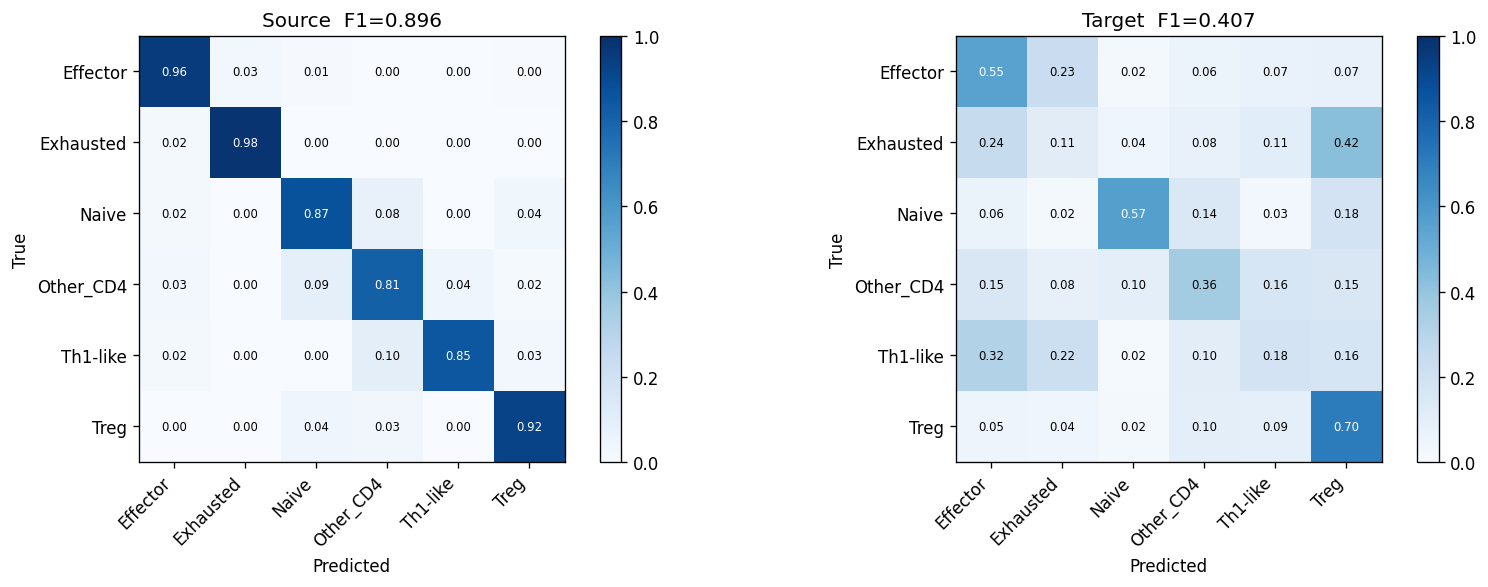

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, y_true, y_pred, title in [
    (axes[0], y_test,        y_pred_src, f'Source  F1={src_f1:.3f}'),
    (axes[1], y_target_eval, y_pred_tgt, f'Target  F1={tgt_f1:.3f}'),
]:
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xticks(range(n_classes)); ax.set_yticks(range(n_classes))
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.set_yticklabels(class_names)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    for i in range(n_classes):
        for j in range(n_classes):
            ax.text(j, i, f'{cm[i,j]:.2f}', ha='center', va='center',
                    color='white' if cm[i,j]>0.5 else 'black', fontsize=7)
    plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confusion_matrices_v3.png', bbox_inches='tight')
plt.show()

## 7. Save + Comparison Table

In [10]:
src_rep = classification_report(y_test,        y_pred_src, target_names=class_names, output_dict=True)
tgt_rep = classification_report(y_target_eval, y_pred_tgt, target_names=class_names, output_dict=True)
results = {
    'model': 'GeneAttentionV3',
    'config': {
        'sigmas': SIGMAS, 'median_dist': median_dist,
        'max_align_weight': 0.5, 'max_ent_weight': 0.1,
        'ramp_epochs': RAMP_EPOCHS, 'coral': True,
        'epochs_trained': len(history.history['ce_loss']),
    },
    'source_test': {'macro_f1': src_f1, 'accuracy': accuracy_score(y_test, y_pred_src),
                    'per_class_f1': {c: src_rep[c]['f1-score'] for c in class_names}},
    'target_eval': {'macro_f1': tgt_f1, 'accuracy': accuracy_score(y_target_eval, y_pred_tgt),
                    'per_class_f1': {c: tgt_rep[c]['f1-score'] for c in class_names}},
}
with open(RESULTS_DIR / 'gene_attention_v3_results.json', 'w') as f:
    json.dump(results, f, indent=2)
model.save_weights(str(RESULTS_DIR / 'gene_attention_v3.weights.h5'))

all_models = [
    ('GeneAtt v2 (CORAL+MMD)',   0.893, 0.404),
    ('DANN v2',                  0.875, 0.395),
    ('VAE + Classifier',         0.881, 0.383),
    ('PatchTransformer',         0.772, 0.384),
    ('GeneAtt v3 (centroid+ent)', src_f1, tgt_f1),
]
best = max(t for _,_,t in all_models)
print(f'\n{"Model":30s} {"Source F1":>10s} {"Target F1":>10s}')
print('-'*54)
for name, sf, tf_ in all_models:
    mark = ' ◄ best' if tf_ == best else ''
    print(f'{name:30s} {sf:10.3f} {tf_:10.3f}{mark}')


Model                           Source F1  Target F1
------------------------------------------------------
GeneAtt v2 (CORAL+MMD)              0.893      0.404
DANN v2                             0.875      0.395
VAE + Classifier                    0.881      0.383
PatchTransformer                    0.772      0.384
GeneAtt v3 (centroid+ent)           0.896      0.407 ◄ best
